In [1]:
import pandas as pd
import json

## Generate instances

In [3]:
!python main.py  --generate-instances

2026-05-17 20:31:31 | INFO | src.main | [run] log file: logs\run-20260517-203131.log
2026-05-17 20:31:33 | INFO | httpx | HTTP Request: POST https://openrouter.ai/api/v1/responses "HTTP/1.1 200 OK"
2026-05-17 20:31:37 | INFO | src.instances | Saved all instances: data-storage\domino_tiling\instances\all_instances.json with 3 instances
2026-05-17 20:31:37 | INFO | src.main | {'openai/gpt-5.1-codex-mini': {'ok': True, 'count': 3, 'path': 'data-storage\\domino_tiling\\instances\\openai_gpt-5.1-codex-mini.json'}}
2026-05-17 20:31:37 | INFO | src.main | [run] logs saved: logs\run-20260517-203131.log


In [4]:
import json

instances = json.load(open('data-storage/domino_tiling/instances/all_instances.json'))
instances

[{'variables': {'m': 3, 'n': 4},
  'case_notes': ['Typical modest stress rectangle covering modest size.'],
  'model_names': ['openai/gpt-5.1-codex-mini']},
 {'variables': {'m': 1, 'n': 8},
  'case_notes': ['Boundary/near-degenerate single row to check horizontal placement.'],
  'model_names': ['openai/gpt-5.1-codex-mini']},
 {'variables': {'m': 2, 'n': 3},
  'case_notes': ['Bug-revealing thin board ensuring alternating domino placements.'],
  'model_names': ['openai/gpt-5.1-codex-mini']}]

## data generation

In [16]:
!python main.py  --data-generation

2026-05-13 09:46:30 | INFO | src.main | [run] log file: logs\run-20260513-094630.log
2026-05-13 09:46:30 | INFO | src.data_generation | [data-gen] starting: problem='domino_tiling', llms=2, languages=2, labels=6, max_rounds=5
2026-05-13 09:46:30 | INFO | src.data_generation | [data-gen] reference model OK (language='CPMpy', solution-space size=281)
2026-05-13 09:46:30 | INFO | src.data_generation | [data-gen] resuming from existing payload: 2 candidate(s) already on disk
2026-05-13 09:46:30 | INFO | src.data_generation | [data-gen] loaded benchmark status: 36 row(s) from logs\benchmark-status.csv
2026-05-13 09:46:30 | INFO | src.data_generation | [openai/gpt-5.1-codex-mini | minizinc] resuming from disk: 2/6 label(s) already captured [non-executable, equivalent]
2026-05-13 09:46:30 | INFO | src.data_generation | [openai/gpt-5.1-codex-mini | minizinc] starting candidate generation for 6 target labels
2026-05-13 09:46:30 | INFO | src.data_generation | [openai/gpt-5.1-codex-mini | minizin

^C


In [5]:
candidates = json.load(open('data-storage/domino_tiling/candidates/candidate-models.json'))
print(json.dumps(candidates, indent=2))

{
  "openai/gpt-5.1-codex-mini": {
    "minizinc": {
      "unsound": {
        "ok": true,
        "code": "% Divergence strategy: encode per-cell tile roles with adjacency pairing constraints instead of enumerating domino starts.\nint: m;\nint: n;\n\narray[1..m, 1..n] of var 0..3: tile;\narray[1..m, 1..n] of var bool: h;\narray[1..m, 1..n] of var bool: v;\n\nconstraint forall(i in 1..m, j in 1..n)(\n  h[i,j] <-> tile[i,j] = 0 /\\\n  v[i,j] <-> tile[i,j] = 2\n);\n\nconstraint forall(i in 1..m, j in 1..n)(\n  tile[i,j] != 0 \\/ j < n\n);\nconstraint forall(i in 1..m, j in 1..n)(\n  tile[i,j] != 1 \\/ j > 1\n);\nconstraint forall(i in 1..m, j in 1..n)(\n  tile[i,j] != 2 \\/ i < m\n);\nconstraint forall(i in 1..m, j in 1..n)(\n  tile[i,j] != 3 \\/ i > 1\n);\n\nconstraint forall(i in 1..m, j in 1..n-1)(\n  tile[i,j] = 0 -> tile[i,j+1] = 1\n);\nconstraint forall(i in 1..m, j in 2..n)(\n  tile[i,j] = 1 -> tile[i,j-1] = 0\n);\nconstraint forall(i in 1..m-1, j in 1..n)(\n  tile[i,j] = 2 -> ti

## Evaluation

#### RQ0: How do common CP evaluation proxies differ from solution-space-based oracle labels?

In [25]:
!python main.py --num-problems 4  --sat-meta-eval

MiniZinc result: 1
MiniZinc stdout: 
MiniZinc stderr: C:\Users\nmofa\AppData\Local\Temp\tmp5l_sq1rv\candidate.mzn:1.1:
# Strategy: COMPREHEND via aggregating adults and half-bushel helpers, DIVERGE by introducing derived adult/half-bushel variables so totals are enforced indirectly

^
Error: syntax error, unexpected invalid token

MiniZinc result: 0
MiniZinc stdout: 
MiniZinc stderr: 
MiniZinc result: 0
MiniZinc stdout: 
MiniZinc stderr: 
MiniZinc result: 0
MiniZinc stdout: 
MiniZinc stderr: 
MiniZinc result: 0
MiniZinc stdout: 
MiniZinc stderr: 
MiniZinc result: 1
MiniZinc stdout: 
MiniZinc stderr: Error: type error: no function or predicate with name `alldifferent' found
C:\Users\nmofa\AppData\Local\Temp\tmppmuxrtoj\candidate.mzn:4.12-34

MiniZinc result: 0
MiniZinc stdout: 
MiniZinc stderr: 
MiniZinc result: 0
MiniZinc stdout: 
MiniZinc stderr: 
MiniZinc result: 0
MiniZinc stdout: 
MiniZinc stderr: 
MiniZinc result: 0
MiniZinc stdout: 
MiniZinc stderr: 
MiniZinc result: 0
MiniZinc s

2026-05-18 10:48:20 | INFO | src.main | [run] log file: logs\run-20260518-104820.log
2026-05-18 10:48:20 | INFO | src.main | [run] loaded 4 problem(s) from extra_files\dcp-bench-open.jsonl
2026-05-18 10:48:20 | INFO | src.main | [run] ── problem 1/4: abbots_puzzle ──
2026-05-18 10:48:20 | INFO | src.meta_eval | [sat-meta-eval] enumerating reference space …
2026-05-18 10:48:20 | INFO | src.meta_eval | [sat-meta-eval] reference space size: 1
2026-05-18 10:48:20 | INFO | src.meta_eval | [sat-meta-eval] starting: 1 generator(s), 10 candidate slots
2026-05-18 10:48:20 | INFO | src.meta_eval | [sat-meta-eval] gen=openai/gpt-5.1-codex-mini | minizinc | claimed='non-executable' -> full_space=non-executable sat_only=False
2026-05-18 10:48:20 | INFO | src.meta_eval | [sat-meta-eval] gen=openai/gpt-5.1-codex-mini | minizinc | claimed='equivalent' -> full_space=equivalent sat_only=True
2026-05-18 10:48:20 | INFO | src.meta_eval | [sat-meta-eval] gen=openai/gpt-5.1-codex-mini | minizinc | claimed='

In [26]:
# showing the results
results = pd.read_csv('data-storage/domino_tiling/candidates/sat-meta-eval-results.csv').fillna("")
results

,generator_llm,language,claimed_label,full_space_observed_label,full_space_correct,exec_status,reference_sat,candidate_sat,solution_in_ref,sat_only_correct,error
0,openai/gpt-5.1-codex-mini,minizinc,unsound,unsound,False,ok,True,True,False,False,
1,openai/gpt-5.1-codex-mini,minizinc,equivalent,equivalent,True,ok,True,True,True,True,
2,openai/gpt-5.1-codex-mini,minizinc,non-executable,non-executable,False,non_executable,True,,,False,MiniZinc syntax check failed: C:\Users\nmofa\A...
3,openai/gpt-5.1-codex-mini,minizinc,incomplete,incomplete,False,ok,True,True,True,True,
4,openai/gpt-5.1-codex-mini,minizinc,unsound-incomplete,unsound-incomplete,False,ok,True,True,False,False,
5,openai/gpt-5.1-codex-mini,CPMpy,equivalent,equivalent,True,ok,True,True,True,True,
6,openai/gpt-5.1-codex-mini,CPMpy,unsound,unsound,False,ok,True,True,False,False,
7,openai/gpt-5.1-codex-mini,CPMpy,incomplete,incomplete,False,ok,True,True,True,True,
8,openai/gpt-5.1-codex-mini,CPMpy,non-executable,non-executable,False,non_executable,True,,,False,NameError: name 'dominoes' is not defined


Also we can assess:
Other data variable instances   ...

In [11]:
summaries = pd.read_csv('data-storage/domino_tiling/candidates/sat-meta-eval-summary.csv').fillna("")
summaries

,view,label,language,total,evaluated,tp,fp,tn,fn,accuracy,precision,recall,f1
0,overall,,,9,7,2,2,3,0,0.7143,0.5,1.0,0.6667
1,by_language,,CPMpy,4,3,1,1,1,0,0.6667,0.5,1.0,0.6667
2,by_language,,minizinc,5,4,1,1,2,0,0.7500,0.5,1.0,0.6667
3,by_claimed_label,equivalent,,2,2,2,0,0,0,1.0000,1.0,1.0,1.0000
4,by_claimed_label,incomplete,,2,2,0,2,0,0,0.0000,0.0,0.0,0.0000
5,by_claimed_label,non-executable,,2,0,0,0,0,0,0.0000,0.0,0.0,0.0000
6,by_claimed_label,unsound,,2,2,0,0,2,0,1.0000,0.0,0.0,0.0000
7,by_claimed_label,unsound-incomplete,,1,1,0,0,1,0,1.0000,0.0,0.0,0.0000
8,by_language_label,equivalent,CPMpy,1,1,1,0,0,0,1.0000,1.0,1.0,1.0000
9,by_language_label,incomplete,CPMpy,1,1,0,1,0,0,0.0000,0.0,0.0,0.0000


In [54]:

df_all.tail()

,generator_llm,language,claimed_label,full_space_observed_label,full_space_correct,exec_status,reference_sat,candidate_sat,solution_in_ref,sat_only_correct,error,problem
4,openai/gpt-5.1-codex-mini,minizinc,unsound-incomplete,unsound-incomplete,False,ok,True,True,False,False,NaN,domino_tiling
5,openai/gpt-5.1-codex-mini,CPMpy,equivalent,equivalent,True,ok,True,True,True,True,NaN,domino_tiling
6,openai/gpt-5.1-codex-mini,CPMpy,unsound,unsound,False,ok,True,True,False,False,NaN,domino_tiling
7,openai/gpt-5.1-codex-mini,CPMpy,incomplete,incomplete,False,ok,True,True,True,True,NaN,domino_tiling
8,openai/gpt-5.1-codex-mini,CPMpy,non-executable,non-executable,False,non_executable,True,NaN,NaN,False,NameError: name 'dominoes' is not defined,domino_tiling


In [52]:
import glob
problems = glob.glob("data-storage/*/candidates/sat-meta-eval-results.csv")
df_all = pd.DataFrame()
for pb in problems:
    # print(pb)
    df = pd.read_csv(pb)
    df['problem'] = pb.split("\\")[-3]
    df_all = pd.concat([df_all, df])


print(len(df_all[(df_all["full_space_correct"] == False) & (df_all["sat_only_correct"] == True)]))
print(len(df_all))

4
39


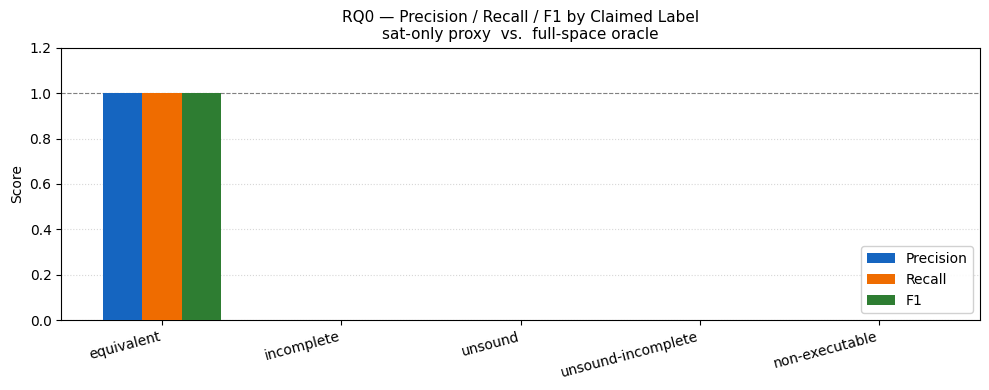

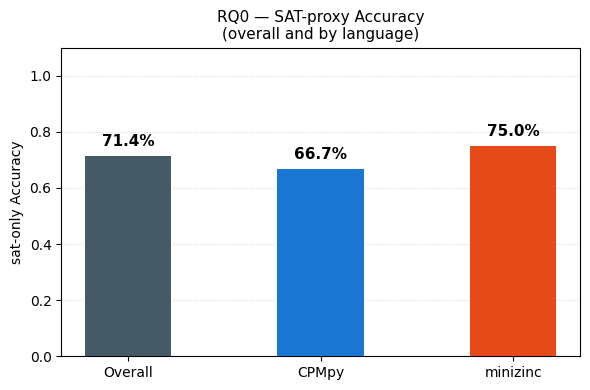

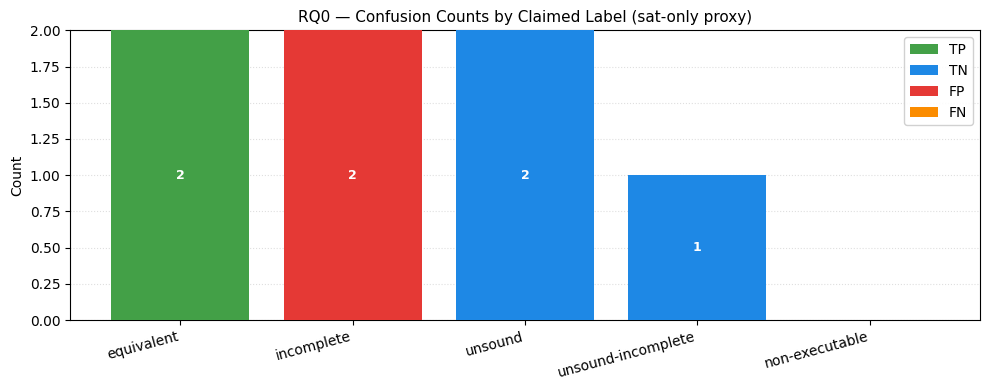

C:\Users\nmofa\AppData\Local\Temp\ipykernel_8596\512959509.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


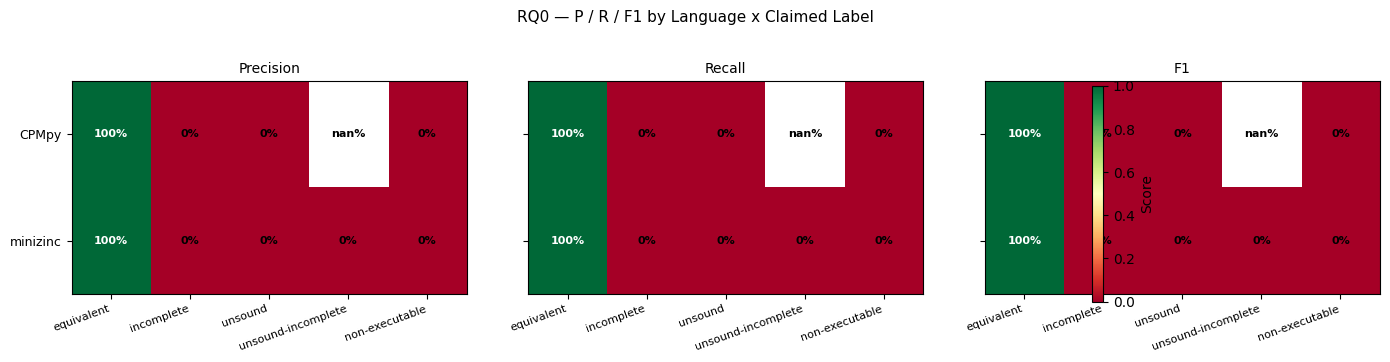

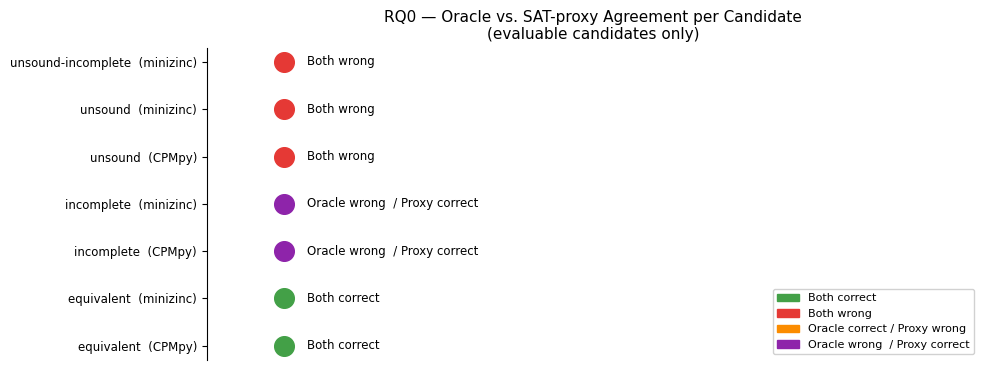

RQ0 figures saved.


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── data ─────────────────────────────────────────────────────────────────────
sat_summary = pd.read_csv('data-storage/domino_tiling/candidates/sat-meta-eval-summary.csv').fillna('')
sat_results  = pd.read_csv('data-storage/domino_tiling/candidates/sat-meta-eval-results.csv').fillna('')

LABEL_ORDER  = ['equivalent', 'incomplete', 'unsound', 'unsound-incomplete', 'non-executable']
LANG_COLORS  = {'CPMpy': '#1976D2', 'minizinc': '#E64A19'}

# ─────────────────────────────────────────────────────────────────────────────
# Fig 1 – Precision / Recall / F1  by claimed label
# ─────────────────────────────────────────────────────────────────────────────
by_label = sat_summary[sat_summary['view'] == 'by_claimed_label'].copy()
by_label = by_label[by_label['label'].isin(LABEL_ORDER)]
by_label['label'] = pd.Categorical(by_label['label'], categories=LABEL_ORDER, ordered=True)
by_label = by_label.sort_values('label')

fig, ax = plt.subplots(figsize=(10, 4))
x, w = np.arange(len(by_label)), 0.22
ax.bar(x - w, by_label['precision'], w, label='Precision', color='#1565C0', zorder=3)
ax.bar(x,     by_label['recall'],    w, label='Recall',    color='#EF6C00', zorder=3)
ax.bar(x + w, by_label['f1'],        w, label='F1',        color='#2E7D32', zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(by_label['label'], rotation=15, ha='right')
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score')
ax.set_title('RQ0 — Precision / Recall / F1 by Claimed Label\n'
             'sat-only proxy  vs.  full-space oracle', fontsize=11)
ax.axhline(1.0, color='grey', lw=0.8, ls='--', zorder=2)
ax.yaxis.grid(True, ls=':', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('rq0_fig1_prf_by_label.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 2 – sat-only Accuracy:  overall  +  by language
# ─────────────────────────────────────────────────────────────────────────────
overall = sat_summary[sat_summary['view'] == 'overall'].iloc[0]
by_lang = sat_summary[sat_summary['view'] == 'by_language'].copy()

groups   = ['Overall'] + list(by_lang['language'])
accuracy = [float(overall['accuracy'])] + list(by_lang['accuracy'].astype(float))
colors   = ['#455A64'] + [LANG_COLORS.get(l, '#888') for l in by_lang['language']]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(groups, accuracy, color=colors, width=0.45, zorder=3)
ax.set_ylim(0, 1.1)
ax.set_ylabel('sat-only Accuracy')
ax.set_title('RQ0 — SAT-proxy Accuracy\n(overall and by language)', fontsize=11)
ax.yaxis.grid(True, ls=':', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for bar, val in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.025,
            f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('rq0_fig2_accuracy_by_language.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 3 – TP / FP / TN / FN stacked bars by claimed label
# ─────────────────────────────────────────────────────────────────────────────
by_label2 = sat_summary[sat_summary['view'] == 'by_claimed_label'].copy()
by_label2 = by_label2[by_label2['label'].isin(LABEL_ORDER)]
by_label2['label'] = pd.Categorical(by_label2['label'], categories=LABEL_ORDER, ordered=True)
by_label2 = by_label2.sort_values('label')

fig, ax = plt.subplots(figsize=(10, 4))
x      = np.arange(len(by_label2))
bottom = np.zeros(len(by_label2))
CONF   = [('tp', '#43A047', 'TP'), ('tn', '#1E88E5', 'TN'),
          ('fp', '#E53935', 'FP'), ('fn', '#FB8C00', 'FN')]
for col, color, lbl in CONF:
    vals = by_label2[col].astype(float).values
    rects = ax.bar(x, vals, bottom=bottom, color=color, label=lbl, zorder=3)
    for rect, v in zip(rects, vals):
        if v > 0:
            ax.text(rect.get_x() + rect.get_width() / 2,
                    rect.get_y() + rect.get_height() / 2,
                    str(int(v)), ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(by_label2['label'], rotation=15, ha='right')
ax.set_ylabel('Count')
ax.set_title('RQ0 — Confusion Counts by Claimed Label (sat-only proxy)', fontsize=11)
ax.yaxis.grid(True, ls=':', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig('rq0_fig3_confusion_by_label.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 4 – P / R / F1 heatmap:  language  x  claimed label
# ─────────────────────────────────────────────────────────────────────────────
by_ll = sat_summary[sat_summary['view'] == 'by_language_label'].copy()
by_ll = by_ll[by_ll['label'].isin(LABEL_ORDER)]
by_ll['label'] = pd.Categorical(by_ll['label'], categories=LABEL_ORDER, ordered=True)

metrics = [('precision', 'Precision'), ('recall', 'Recall'), ('f1', 'F1')]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, (metric, title) in zip(axes, metrics):
    pivot = by_ll.pivot_table(index='language', columns='label', values=metric)
    pivot = pivot.reindex(columns=LABEL_ORDER)
    im = ax.imshow(pivot.values.astype(float), vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=20, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=10)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = float(pivot.values[i, j] or 0)
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=8, fontweight='bold',
                    color='white' if val > 0.85 else 'black')
fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label='Score')
fig.suptitle('RQ0 — P / R / F1 by Language x Claimed Label', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('rq0_fig4_prf_heatmap_lang_label.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 5 – Oracle vs. sat-proxy agreement per candidate (dot chart)
# ─────────────────────────────────────────────────────────────────────────────
def _agree(row):
    fs = row['full_space_correct'] in (True, 'True')
    so = row['sat_only_correct']   in (True, 'True')
    if fs and so:         return 'Both correct'
    if not fs and not so: return 'Both wrong'
    if fs and not so:     return 'Oracle correct / Proxy wrong'
    return                       'Oracle wrong  / Proxy correct'

evaluable = sat_results[sat_results['exec_status'] == 'ok'].copy()
evaluable['agreement'] = evaluable.apply(_agree, axis=1)
evaluable['label_cat'] = pd.Categorical(
    evaluable['claimed_label'], categories=LABEL_ORDER, ordered=True)
evaluable = evaluable.sort_values(['label_cat', 'language']).reset_index(drop=True)

CAT_ORDER  = ['Both correct', 'Both wrong',
              'Oracle correct / Proxy wrong', 'Oracle wrong  / Proxy correct']
CAT_COLORS = {'Both correct':                 '#43A047',
              'Both wrong':                   '#E53935',
              'Oracle correct / Proxy wrong': '#FB8C00',
              'Oracle wrong  / Proxy correct':'#8E24AA'}

fig, ax = plt.subplots(figsize=(10, 3.8))
y_labels = [f"{r['claimed_label']}  ({r['language']})" for _, r in evaluable.iterrows()]
for i, (_, row) in enumerate(evaluable.iterrows()):
    cat = row['agreement']
    ax.scatter(0.5, i, s=200, color=CAT_COLORS[cat], zorder=3, clip_on=False)
    ax.text(0.65, i, cat, va='center', fontsize=8.5)
ax.set_yticks(range(len(evaluable)))
ax.set_yticklabels(y_labels, fontsize=8.5)
ax.set_xlim(0, 5)
ax.set_xticks([])
ax.set_title('RQ0 — Oracle vs. SAT-proxy Agreement per Candidate\n'
             '(evaluable candidates only)', fontsize=11)
legend_patches = [mpatches.Patch(color=CAT_COLORS[c], label=c) for c in CAT_ORDER]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, framealpha=0.9)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('rq0_fig5_agreement_per_candidate.png', dpi=150)
plt.show()

print('RQ0 figures saved.')

### llm-as-judge

#### RQ1: How accurately can LLM judges identify CP-specific semantic correctness labels?
#### RQ3: Which context helps judges?

In [2]:
!python main.py --num-problems 4  --judge --judge-approach reference_free reference_based

2026-05-18 15:16:50 | INFO | src.main | [run] log file: logs\run-20260518-151650.log
2026-05-18 15:16:50 | INFO | src.main | [run] loaded 4 problem(s) from extra_files\dcp-bench-open.jsonl
2026-05-18 15:16:50 | INFO | src.main | [run] ── problem 1/4: abbots_puzzle ──
2026-05-18 15:16:50 | INFO | src.judge | [judge] loading candidates from disk: data-storage\abbots_puzzle\candidates\candidate-models.json
2026-05-18 15:16:50 | INFO | src.judge | [judge] creating judge status file: logs\judge-status.csv
2026-05-18 15:16:50 | INFO | src.judge | [judge] starting: approach=reference_free, judges=1, generators=1, candidate slots=10
2026-05-18 15:16:50 | INFO | src.judge | [judge=openai/gpt-5.4-mini][approach=reference_free] starting
2026-05-18 15:16:52 | INFO | httpx | HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-18 15:16:53 | INFO | src.judge | [judge=openai/gpt-5.4-mini][approach=reference_free] gen=openai/gpt-5.1-codex-mini | minizinc | claimed

In [17]:
# showing the results

results = pd.read_csv('data-storage/domino_tiling/candidates/judge-results.csv')
results

,judge_llm,approach,generator_llm,language,claimed_label,predicted_label,match,confidence,rationale,raw_reply
0,openai/gpt-5.4-mini,reference_free,openai/gpt-5.1-codex-mini,minizinc,unsound,non-executable,False,0.98,"The model is syntactically close to MiniZinc, ...","{""label"":""non-executable"",""confidence"":0.98,""r..."
1,openai/gpt-5.4-mini,reference_free,openai/gpt-5.1-codex-mini,minizinc,equivalent,equivalent,True,0.76,The model is executable MiniZinc and enforces ...,"{""label"":""equivalent"",""confidence"":0.76,""ratio..."
2,openai/gpt-5.4-mini,reference_free,openai/gpt-5.1-codex-mini,minizinc,non-executable,incomplete,False,0.97,The model is executable and correctly enforces...,"{""label"":""incomplete"",""confidence"":0.97,""ratio..."
3,openai/gpt-5.4-mini,reference_free,openai/gpt-5.1-codex-mini,minizinc,incomplete,incomplete,True,0.98,The model is executable and correctly enforces...,"{""label"":""incomplete"",""confidence"":0.98,""ratio..."
4,openai/gpt-5.4-mini,reference_free,openai/gpt-5.1-codex-mini,minizinc,unsound-incomplete,unsound-incomplete,True,0.98,"The model is executable, but the only coverage...","{""label"":""unsound-incomplete"",""confidence"":0.9..."
5,openai/gpt-5.4-mini,reference_free,openai/gpt-5.1-codex-mini,CPMpy,equivalent,unsound,False,0.97,"The code is executable CPMpy, but it does not ...","{""label"":""unsound"",""confidence"":0.97,""rational..."
6,openai/gpt-5.4-mini,reference_free,openai/gpt-5.1-codex-mini,CPMpy,unsound,unsound,True,0.99,"The model is executable, but it only requires ...","{""label"":""unsound"",""confidence"":0.99,""rational..."
7,openai/gpt-5.4-mini,reference_free,openai/gpt-5.1-codex-mini,CPMpy,incomplete,incomplete,True,0.94,The model is executable and correctly enforces...,"{""label"":""incomplete"",""confidence"":0.94,""ratio..."
8,openai/gpt-5.4-mini,reference_free,openai/gpt-5.1-codex-mini,CPMpy,non-executable,non-executable,True,0.99,The program references undefined variable `dom...,"{""label"":""non-executable"",""confidence"":0.99,""r..."
9,openai/gpt-5.4-mini,reference_based,openai/gpt-5.1-codex-mini,minizinc,unsound,unsound-incomplete,False,0.97,"The candidate is executable MiniZinc, but it d...","{""label"":""unsound-incomplete"",""confidence"":0.9..."


In [ ]:
summaries = pd.read_csv('data-storage/domino_tiling/candidates/judge-summary.csv').fillna("")
summaries




,view,approach,judge_llm,language,label,correct,total,accuracy
0,overall,,,,,11,18,0.611111
1,by_judge_language_approach,reference_based,openai/gpt-5.4-mini,CPMpy,,2,4,0.500000
2,by_judge_language_approach,reference_based,openai/gpt-5.4-mini,minizinc,,3,5,0.600000
3,by_judge_language_approach,reference_free,openai/gpt-5.4-mini,CPMpy,,3,4,0.750000
4,by_judge_language_approach,reference_free,openai/gpt-5.4-mini,minizinc,,3,5,0.600000
5,by_judge_language_approach_label,reference_based,openai/gpt-5.4-mini,CPMpy,equivalent,0,1,0.000000
6,by_judge_language_approach_label,reference_based,openai/gpt-5.4-mini,CPMpy,incomplete,0,1,0.000000
7,by_judge_language_approach_label,reference_based,openai/gpt-5.4-mini,CPMpy,non-executable,1,1,1.000000
8,by_judge_language_approach_label,reference_based,openai/gpt-5.4-mini,CPMpy,unsound,1,1,1.000000
9,by_judge_language_approach_label,reference_based,openai/gpt-5.4-mini,minizinc,equivalent,1,1,1.000000


<span style="color:red"><b>Issue:</b> Reference is always in one language! </span>

#### RQ1 and  RQ3: problem families

In [3]:
judges = pd.read_csv("logs/judge-status.csv")
judges["correct"] = (judges["succeed"] == "yes").astype(int)

def agg(df, group_cols):
    return (
        df.groupby(group_cols)["correct"]
        .agg(correct="sum", total="count")
        .reset_index()
        .assign(accuracy=lambda x: x["correct"] / x["total"])
    )

# Row 0: overall
overall = pd.DataFrame([{
    "view": "overall",
    "correct": judges["correct"].sum(),
    "total": len(judges),
    "accuracy": judges["correct"].mean(),
}])

# Rows 1–4: by judge + language + approach
by_jla = agg(judges, ["judge_llm", "language", "approach"])
by_jla.insert(0, "view", "by_judge_language_approach")

# Rows 5+: by judge + language + approach + label
by_jlal = agg(judges, ["judge_llm", "language", "approach", "label"])
by_jlal.insert(0, "view", "by_judge_language_approach_label")

# Combine
summary = pd.concat([overall, by_jla, by_jlal], ignore_index=True)
summary.fillna("")

,view,correct,total,accuracy,judge_llm,language,approach,label
0,overall,45,74,0.608108,,,,
1,by_judge_language_approach,14,19,0.736842,openai/gpt-5.4-mini,CPMpy,reference_based,
2,by_judge_language_approach,13,19,0.684211,openai/gpt-5.4-mini,CPMpy,reference_free,
3,by_judge_language_approach,10,18,0.555556,openai/gpt-5.4-mini,minizinc,reference_based,
4,by_judge_language_approach,8,18,0.444444,openai/gpt-5.4-mini,minizinc,reference_free,
5,by_judge_language_approach_label,2,3,0.666667,openai/gpt-5.4-mini,CPMpy,reference_based,equivalent
6,by_judge_language_approach_label,2,4,0.500000,openai/gpt-5.4-mini,CPMpy,reference_based,incomplete
7,by_judge_language_approach_label,3,4,0.750000,openai/gpt-5.4-mini,CPMpy,reference_based,non-executable
8,by_judge_language_approach_label,3,4,0.750000,openai/gpt-5.4-mini,CPMpy,reference_based,unsound
9,by_judge_language_approach_label,4,4,1.000000,openai/gpt-5.4-mini,CPMpy,reference_based,unsound-incomplete


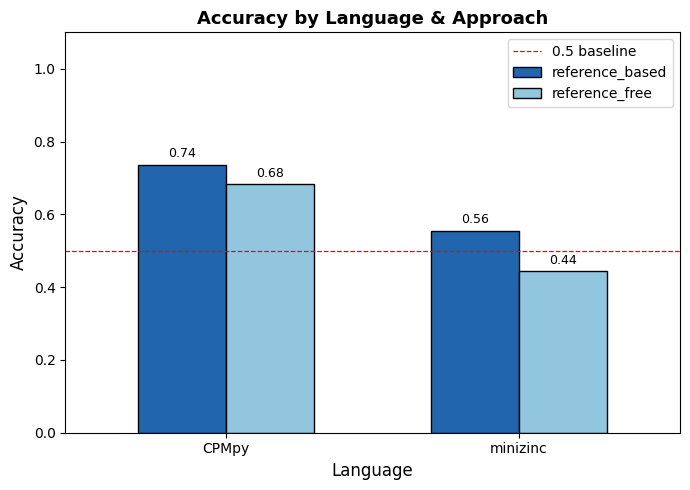

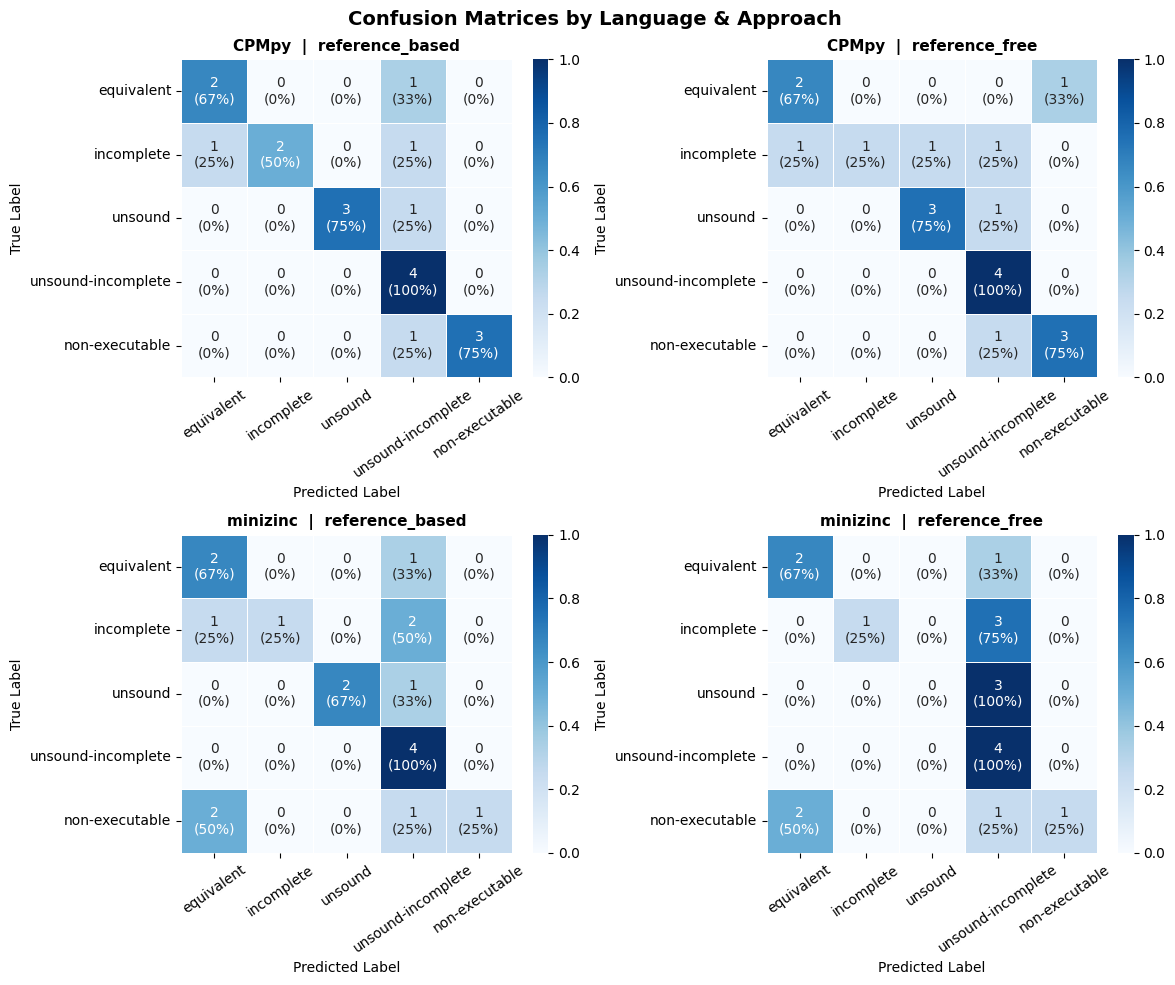

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels_order = ["equivalent", "incomplete", "unsound", "unsound-incomplete", "non-executable"]
languages = sorted(judges["language"].unique())
approaches = sorted(judges["approach"].unique())

# ── Figure 1: Accuracy by language × approach ────────────────────────────
by_jla_plot = agg(judges, ["language", "approach"])
pivot = by_jla_plot.pivot(index="language", columns="approach", values="accuracy")

fig, ax = plt.subplots(figsize=(7, 5))
pivot.plot(kind="bar", ax=ax, ylim=(0, 1.1), rot=0,
           color=["#2166AC", "#92C5DE"], edgecolor="black", width=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

ax.axhline(0.5, color="red", linestyle="--", linewidth=0.9, label="0.5 baseline")
ax.set_title("Accuracy by Language & Approach", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xlabel("Language", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig_accuracy_language_approach.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: Confusion matrices (language × approach) ───────────────────
fig, axes = plt.subplots(len(languages), len(approaches),
                         figsize=(6 * len(approaches), 5 * len(languages)))

for i, lang in enumerate(languages):
    for j, approach in enumerate(approaches):
        ax = axes[i][j]
        subset = judges[(judges["language"] == lang) & (judges["approach"] == approach)]
        cm = confusion_matrix(subset["label"], subset["judgment"], labels=labels_order)

        # Normalize for color, annotate with raw counts
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        annot = [[f"{cm[r][c]}\n({cm_norm[r][c]:.0%})" for c in range(len(labels_order))]
                 for r in range(len(labels_order))]

        sns.heatmap(
            cm_norm, ax=ax, annot=annot, fmt="",
            cmap="Blues", vmin=0, vmax=1, linewidths=0.5,
            xticklabels=labels_order, yticklabels=labels_order,
            cbar=True
        )
        ax.set_title(f"{lang}  |  {approach}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicted Label", fontsize=10)
        ax.set_ylabel("True Label", fontsize=10)
        ax.tick_params(axis="x", rotation=35)
        ax.tick_params(axis="y", rotation=0)

plt.suptitle("Confusion Matrices by Language & Approach", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

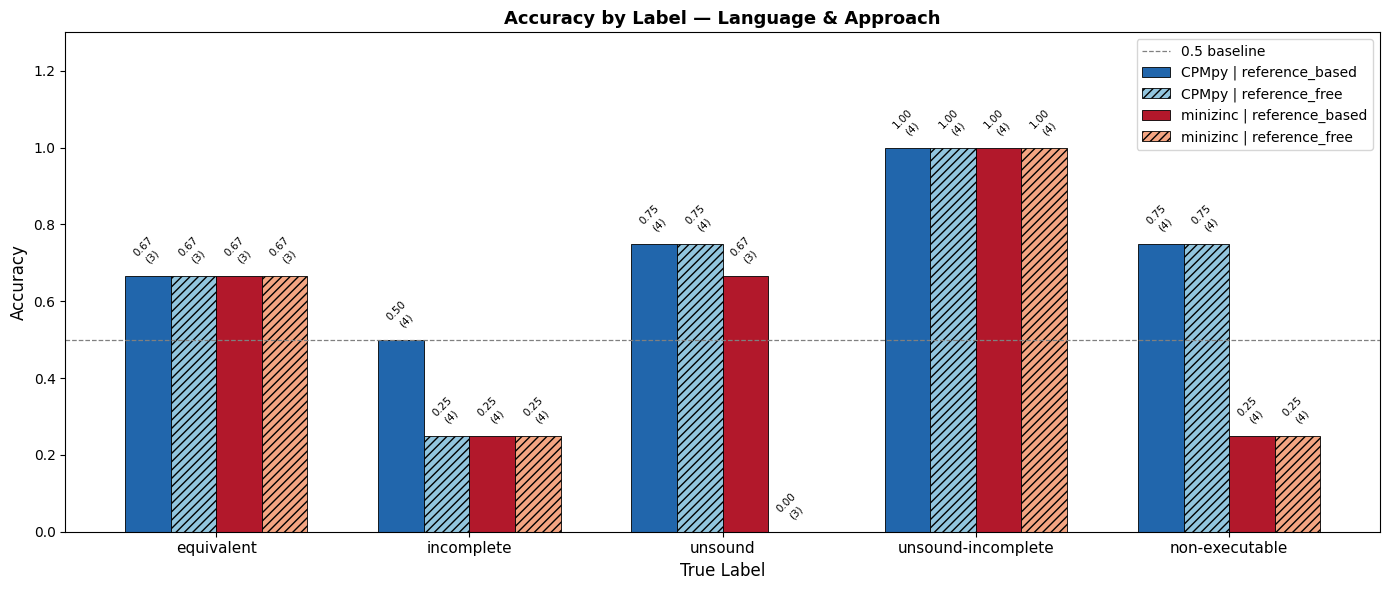

In [6]:
import matplotlib.pyplot as plt
import numpy as np

labels_order = ["equivalent", "incomplete", "unsound", "unsound-incomplete", "non-executable"]
languages = sorted(judges["language"].unique())
approaches = sorted(judges["approach"].unique())

# Same language → similar colors (light/dark shade)
# Same approach → same hatch pattern
color_map = {
    ("CPMpy",    "reference_based"): "#2166AC",   # dark blue
    ("CPMpy",    "reference_free"):  "#92C5DE",   # light blue
    ("minizinc", "reference_based"): "#B2182B",   # dark red
    ("minizinc", "reference_free"):  "#F4A582",   # light red/salmon
}
hatch_map = {
    "reference_based": "",       # solid
    "reference_free":  "////",   # hatched
}

combos = [(lang, app) for lang in languages for app in approaches]
x = np.arange(len(labels_order))
n = len(combos)
bar_width = 0.18
offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * bar_width

fig, ax = plt.subplots(figsize=(14, 6))

for (lang, approach), offset in zip(combos, offsets):
    subset = judges[(judges["language"] == lang) & (judges["approach"] == approach)]
    acc = subset.groupby("label")["correct"].mean().reindex(labels_order)
    cnt = subset.groupby("label")["correct"].count().reindex(labels_order)

    bars = ax.bar(
        x + offset, acc.values,
        width=bar_width,
        label=f"{lang} | {approach}",
        color=color_map[(lang, approach)],
        hatch=hatch_map[approach],
        edgecolor="black", linewidth=0.6
    )
    for bar, val, n_val in zip(bars, acc.values, cnt.values):
        if not np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 0.02,
                f"{val:.2f}\n({int(n_val)})",
                ha="center", va="bottom", fontsize=7.5, rotation=45, linespacing=1.4
            )

ax.set_xticks(x)
ax.set_xticklabels(labels_order, fontsize=11)
ax.set_ylim(0, 1.3)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xlabel("True Label", fontsize=12)
ax.set_title("Accuracy by Label — Language & Approach", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.9, label="0.5 baseline")

# Legend with hatch explanation
ax.legend( fontsize=10)

plt.tight_layout()
plt.savefig("figures/fig_accuracy_by_label.png", dpi=150, bbox_inches="tight")
plt.show()

## Paper 2

#### RQ2: Can LLM judges correctly prefer candidates that are semantically closer to the reference solution space?

Prompt: """
You are an expert CP model judge.
Compare the two candidate models below and decide which better solves the problem.

Allowed decisions:
  "A"   : Candidate A is clearly better (more correct, more complete, or more sound).
  "B"   : Candidate B is clearly better.
  "tie" : Both are equally good or equally flawed; no meaningful difference.

Output format (STRICT JSON only):
{{"winner": "<A|B|tie>", "confidence": <0..1>, "rationale": "<1-3 short sentences>"}}

Problem description:
{context.problem_description}

Candidate A ({language}):
{code_a}

Candidate B ({language}):
{code_b}
"""

In [28]:
!python main.py --pairwise-judge

2026-05-13 10:28:36 | INFO | src.main | [run] log file: logs\run-20260513-102836.log
2026-05-13 10:28:36 | INFO | src.pairwise_judge | [pairwise] loaded existing status: 102 row(s) from logs\pairwise-judge-status.csv
2026-05-13 10:28:36 | INFO | src.pairwise_judge | [pairwise] starting: judges=2, languages=2, total pairs=39
2026-05-13 10:28:36 | INFO | src.pairwise_judge | [pairwise-judge=openai/gpt-4o-mini] minizinc | A=(openai/gpt-5.1-codex-mini,non-executable) vs B=(openai/gpt-5.1-codex-mini,equivalent) -> skipped (already done)
2026-05-13 10:28:36 | INFO | src.pairwise_judge | [pairwise-judge=openai/gpt-4o-mini] minizinc | A=(openai/gpt-5.1-codex-mini,non-executable) vs B=(openai/gpt-4o-mini,non-executable) -> skipped (already done)
2026-05-13 10:28:36 | INFO | src.pairwise_judge | [pairwise-judge=openai/gpt-4o-mini] minizinc | A=(openai/gpt-5.1-codex-mini,equivalent) vs B=(openai/gpt-4o-mini,non-executable) -> skipped (already done)
2026-05-13 10:28:36 | INFO | src.pairwise_judge 

In [29]:
results = pd.read_csv('data-storage/domino_tiling/candidates/pairwise-results.csv')
results

,judge_llm,language,generator_llm_a,claimed_label_a,generator_llm_b,claimed_label_b,winner,confidence,rationale,raw_reply
0,openai/gpt-4o-mini,CPMpy,openai/gpt-5.1-codex-mini,equivalent,openai/gpt-4o-mini,incomplete,A,0.90,Candidate A correctly ensures that all squares...,"{""winner"": ""A"", ""confidence"": 0.9, ""rationale""..."
1,openai/gpt-4o-mini,CPMpy,openai/gpt-5.1-codex-mini,unsound-incomplete,openai/gpt-4o-mini,incomplete,A,0.90,Candidate A correctly ensures that each square...,"```json\n{""winner"": ""A"", ""confidence"": 0.9, ""r..."
2,openai/gpt-4o-mini,CPMpy,openai/gpt-5.1-codex-mini,incomplete,openai/gpt-4o-mini,incomplete,A,0.90,Candidate A ensures that the total number of d...,"{""winner"": ""A"", ""confidence"": 0.9, ""rationale""..."
3,openai/gpt-4o-mini,CPMpy,openai/gpt-5.1-codex-mini,non-executable,openai/gpt-4o-mini,incomplete,A,0.90,Candidate A ensures that every square of the b...,"{""winner"": ""A"", ""confidence"": 0.9, ""rationale""..."
4,openai/gpt-4o-mini,CPMpy,openai/gpt-5.1-codex-mini,status-only correct,openai/gpt-4o-mini,incomplete,A,0.90,Candidate A provides a clear and fixed tiling ...,"{""winner"": ""A"", ""confidence"": 0.9, ""rationale""..."
5,openai/gpt-4o-mini,CPMpy,openai/gpt-4o-mini,equivalent,openai/gpt-4o-mini,incomplete,A,0.90,Candidate A correctly enforces the tiling cons...,"{""winner"": ""A"", ""confidence"": 0.9, ""rationale""..."
6,openai/gpt-4o-mini,CPMpy,openai/gpt-4o-mini,incomplete,openai/gpt-4o-mini,unsound-incomplete,tie,0.50,Both candidates have significant flaws related...,"```json\n{""winner"": ""tie"", ""confidence"": 0.5, ..."
7,openai/gpt-4o-mini,CPMpy,openai/gpt-4o-mini,incomplete,openai/gpt-4o-mini,status-only correct,A,0.70,Candidate A attempts to ensure each cell is co...,"```json\n{""winner"": ""A"", ""confidence"": 0.7, ""r..."
8,openai/gpt-5.4-mini,CPMpy,openai/gpt-5.1-codex-mini,equivalent,openai/gpt-4o-mini,incomplete,A,0.99,Candidate A correctly models domino coverage w...,"{""winner"":""A"",""confidence"":0.99,""rationale"":""C..."
9,openai/gpt-5.4-mini,CPMpy,openai/gpt-5.1-codex-mini,unsound-incomplete,openai/gpt-4o-mini,incomplete,A,0.99,Candidate A correctly enforces exact coverage ...,"{""winner"":""A"",""confidence"":0.99,""rationale"":""C..."


Which pairs?
different language of pairs?
different generator llm of pairs?


#### RQ4: How robust are LLM judges to variations in evaluation conditions?

#### RQ5: Is the benchmark useful for generation workflows?
OR
RQ5: Can LLM judge's scores and feedback improve candidate CP model generation workflows?


for next paper ?

In [39]:
from pathlib import Path
from src.config import contexts_from_jsonl

contexts = contexts_from_jsonl(
    Path("extra_files/dcp-bench-open.jsonl"),
    num_problems=4,
)

for ctx in contexts:
    print(f"{'='*60}")
    print(f"  Problem ID : {ctx.targeted_id}")
    print(f"{'='*60}")
    print(f"\n[Description]\n{ctx.problem_description}")
    print(f"\n[Reference CP Model]\n{ctx.reference_cp_model}")
    if ctx.data_instances:
        print(f"\n[Data Instances] ({len(ctx.data_instances)} total)")
        for i, inst in enumerate(ctx.data_instances, 1):
            print(f"  Instance {i}: {inst}")
    else:
        print(f"\n[Data Instances] None")
    print()


  Problem ID : abbots_puzzle

[Description]
If 100 bushels of corn were distributed among 100 people such that each man received three bushels, each woman two, and each child half a bushel, and there are five times as many women as men, find the number of men, women, and children.  Print the number of men, women, and children (men, women, children).

[Reference CP Model]
# Import libraries
from cpmpy import *
import json

# Decision variables
men = intvar(0, 100, name="men")
women = intvar(0, 100, name="women")
children = intvar(0, 100, name="children")

# Model
model = Model([
    men + women + children == 100,  # Total number of people
    men * 6 + women * 4 + children == 200,  # Total bushels of corn
    men * 5 == women  # Five times as many women as men
])

# Solve the model
model.solve()

# Print the solution
solution = {
    "men": men.value(),
    "women": women.value(),
    "children": children.value()
}
print(json.dumps(solution))
# End of CPMPy script

[Data Instances] None